# Polynomial regression

This notebook aims to illustrate the basic concepts of machine learning, using polynomial regression as an example.

## Data generation

For illustration purposes we will generate a synthetic dataset such that:
$$ y = f(x) + \epsilon $$
where $f$ is a (unknown) function, $\epsilon$ is a Gaussian noise and such that $x \sim \mathcal{U}(0, 1)$.

The function $f$ we will use is $f(x) = \cos(1.5 \pi x)$.

In [1]:
import numpy as np

def f(x):
    """The unknown function to be approximated"""
    return np.cos(1.5 * np.pi * x)

def generate(n, sigma=0.2):
    """Sample n points from the data generating process."""
    x = np.random.rand(n)       # U[0, 1]
    y = f(x) + sigma * np.random.randn(n)  # f(x) + noise
    return x, y

<span style="color: blue">Using the matplotlib library, plot the true function and 20 points, generated using the function above.</span>

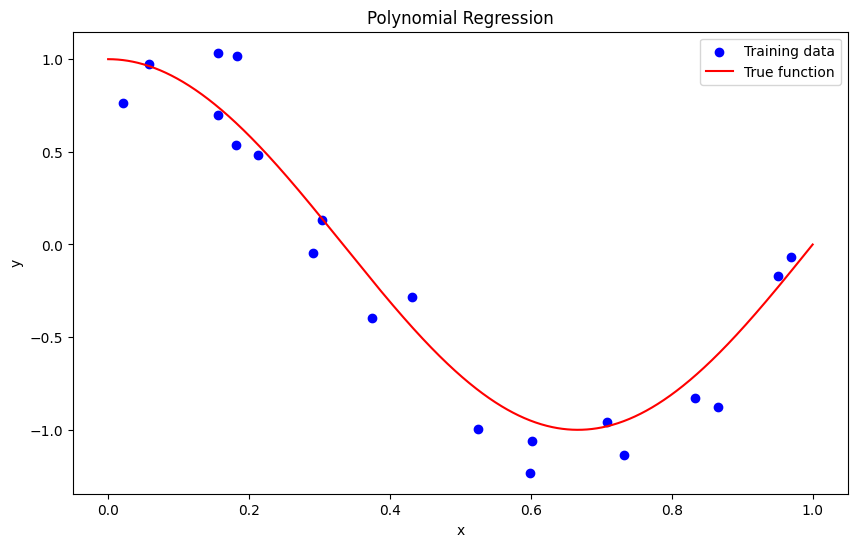

In [2]:
import matplotlib.pyplot as plt

np.random.seed(42)  # For reproducibility
x_train, y_train = generate(20)
xs = np.linspace(0, 1, 1000)

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, color='blue', label='Training data')
plt.plot(xs, f(xs), color='red', label='True function')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Regression')
plt.legend()
plt.show()

The Scikit-learn library provides an implementation of polynomial regression, which we will use in this notebook. The following code illustrates how to use this implementation on the synthetic dataset we generated above. We will use a polynomial of degree 10 to fit the data.

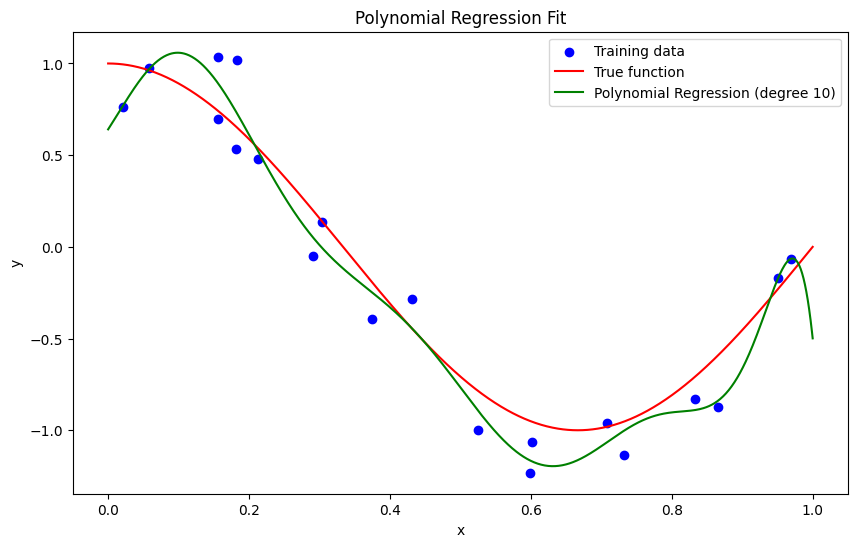

In [3]:
# Polynomial Regression using Scikit-learn
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly_features = PolynomialFeatures(degree=10)
linear_regression = LinearRegression()
X_train_poly = poly_features.fit_transform(x_train.reshape(-1, 1))
linear_regression.fit(X_train_poly, y_train)

# TODO: plot the results
plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, color='blue', label='Training data')
xs = np.linspace(0, 1, 1000)
X_test_poly = poly_features.transform(xs.reshape(-1, 1))
y_pred = linear_regression.predict(X_test_poly)
plt.plot(xs, f(xs), color='red', label='True function')
plt.plot(xs, y_pred, color='green', label='Polynomial Regression (degree 10)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Regression Fit')
plt.legend()
plt.show()


Taking inspiration from the previous example, the goal is now to compare polynomial regression models with different degrees, and to determine which degree fit the best the true function. To do so, we will generate two datasets of 100 points each, one for the training and one for the test. We will then fit polynomial regression models of different degrees on the training dataset, and evaluate their performance on the test dataset. The performance will be measured using the mean squared error (MSE) between the predicted values and the true values.

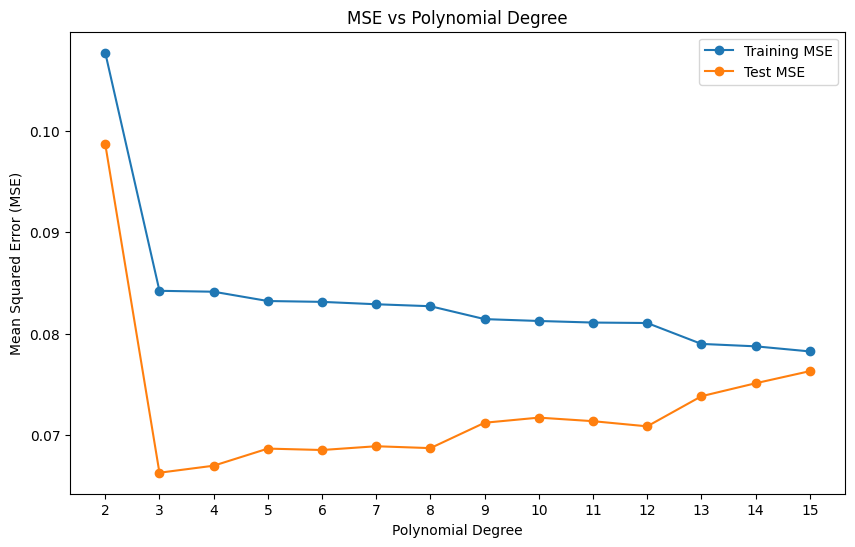

In [4]:
# TODO: generate the two datasets of 100 points each, using the 'generate' function, and using the same noise level for both datasets.
x_train, y_train = generate(100, sigma=0.3)
x_test, y_test = generate(100, sigma=0.3)

# TODO: fit polynomial regression models of different degrees on the training dataset, and evaluate their performance on the test dataset. The performance will be measured using the mean squared error (MSE) between the predicted values and the true values.
degrees = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
mse_train = []
mse_test = []
for degree in degrees:
    poly_features = PolynomialFeatures(degree=degree)
    linear_regression = LinearRegression()
    
    # Transform the training data
    X_train_poly = poly_features.fit_transform(x_train.reshape(-1, 1))
    linear_regression.fit(X_train_poly, y_train)
    
    # Predict on training data
    y_train_pred = linear_regression.predict(X_train_poly)
    mse_train.append(np.mean((y_train - y_train_pred) ** 2))
    
    # Transform the test data
    X_test_poly = poly_features.transform(x_test.reshape(-1, 1))
    y_test_pred = linear_regression.predict(X_test_poly)
    mse_test.append(np.mean((y_test - y_test_pred) ** 2))

# Plot the MSE for training and test data
plt.figure(figsize=(10, 6))
plt.plot(degrees, mse_train, marker='o', label='Training MSE')
plt.plot(degrees, mse_test, marker='o', label='Test MSE')
plt.xlabel('Polynomial Degree')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE vs Polynomial Degree')
plt.xticks(degrees)
plt.legend()
plt.show()


<span style="color: blue;">According to these results, what would be the optimal degree for the polynomial regression model? On the same figure, plot below the resulting polynomial fit along with the test data and the true function.</span>


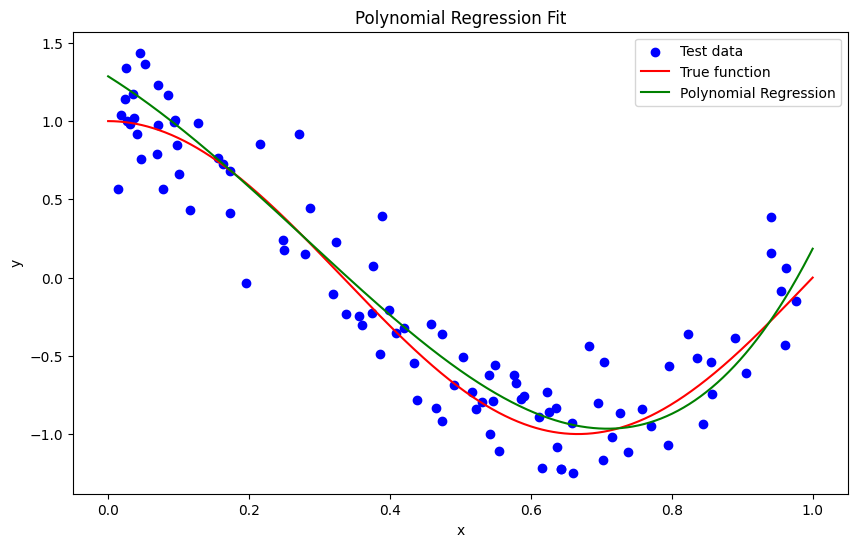

In [5]:
poly_features = PolynomialFeatures(degree=4)
linear_regression = LinearRegression()
X_train_poly = poly_features.fit_transform(x_train.reshape(-1, 1))
linear_regression.fit(X_train_poly, y_train)

# TODO: plot the results
plt.figure(figsize=(10, 6))
plt.scatter(x_test, y_test, color='blue', label='Test data')
xs = np.linspace(0, 1, 1000)
X_test_poly = poly_features.transform(xs.reshape(-1, 1))
y_pred = linear_regression.predict(X_test_poly)
plt.plot(xs, f(xs), color='red', label='True function')
plt.plot(xs, y_pred, color='green', label='Polynomial Regression')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Polynomial Regression Fit')
plt.legend()
plt.show()